# Intro

We decided to find the best neighborhood in Pittsburgh by comparing each neighborhood's average daily traffic, median age of death, and yearly crime.  We decided to use traffic data because it is a good representation of how annoying it is to drive around in an area, so we decided that a low traffic count was good.  We decided to use median age at death because we decided that neighborhoods that allow a person to live longer statistically are better.  We decided to use yearly crime because gauging yearly crime is a viable way of grasping the level of safety a neighborhood provides. First, we must recognize what results came from every sector of data interpreted by each member.

# mst79 Median Age at Death Data Analysis

### Total Deaths and Median Age of Death by Neighborhood

[This dataset](https://data.wprdc.org/dataset/median-age-death) contains the deaths and median age at death for all the neighborhoods in Pittsburgh over the years 2011-2015. The deaths are of individuals with residences in the neighborhood. While the data isn't as current, being from the 2010s, which are now over a decade ago, we think that it still serves as a good indicator to compare the neighborhoods with. The dataset also contains breakdowns by certain races, but this won't be considered for the purposes of the metric.

The submetric we will be using is an unweighted combination of the neighborhood rankings in both the total deaths and median age at death. Essentially, the placement of each neighborhood is its score for that column and the sum of its scores will be the submetric. The lower the score, the higher the placement for the submetric (like golf). In the end, we will sort by ascending order of score and that final placement will be the submetric.

### Total Deaths and Median Age of Death by Neighborhood

[This dataset](https://data.wprdc.org/dataset/median-age-death) contains the deaths and median age at death for all the neighborhoods in Pittsburgh over the years 2011-2015. The deaths are of individuals with residences in the neighborhood. While the data isn't as current, being from the 2010s, which are now over a decade ago, we think that it still serves as a good indicator to compare the neighborhoods with. The dataset also contains breakdowns by certain races, but this won't be considered for the purposes of the metric.

The submetric we will be using is an unweighted combination of the neighborhood rankings in both the total deaths and median age at death. Essentially, the placement of each neighborhood is its score for that column and the sum of its scores will be the submetric. The lower the score, the higher the placement for the submetric (like golf). In the end, we will sort by ascending order of score and that final placement will be the submetric.

---

### Setup

In [50]:
# Import the required module
import pandas as pd

# Load the .csv file from the database
og_data = pd.read_csv("median_age_death.csv")

# Print out the first 5 rows
og_data.head(5)

,_id,NEIGHBORHOOD,BLACKdeaths,Black MD AGE AT DEATH,WHITEdeaths,White MD AGE AT DEATH,TOTALdeaths*,TOTAL MD AGE AT DEATH
0,1,SOUTH SHORE,0.0,0.0,0.0,0.0,0.0,0.0
1,2,CHATEAU,0.0,0.0,2.0,NaN,2.0,NaN
2,3,NORTH SHORE,0.0,0.0,4.0,NaN,5.0,80.0
3,4,ALLEGHENY WEST,3.0,NaN,4.0,NaN,8.0,65.0
4,5,SAINT CLAIR,5.0,67.5,5.0,67.5,10.0,67.5


In [51]:
# Print out the last 5 rows
og_data.tail(5)

,_id,NEIGHBORHOOD,BLACKdeaths,Black MD AGE AT DEATH,WHITEdeaths,White MD AGE AT DEATH,TOTALdeaths*,TOTAL MD AGE AT DEATH
87,88,CARRICK,35.0,59.4,622.0,77.0,678.0,75.9
88,89,BROOKLINE,13.0,61.2,723.0,78.1,750.0,77.8
89,90,SQUIRREL HILL SOUTH,58.0,83.2,721.0,86.2,802.0,85.9
90,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91,92,*Total includes Other and Unknown race.,NaN,NaN,NaN,NaN,NaN,NaN


Looking at this database, the most relevant categorical data is the Neighborhood, and the relevant quantitative data are in the columns "TOTALdeaths" and "TOTAL MD AGE AT DEATH". So, we drop the unnecessary columns of data by creating a new DataFrame containing only the columns we want. We do not care about the race for our purposes here in ranking the neighborhoods, and therefore, we only care about the total.

Furthermore, we also only want rows for neighborhoods as the database actually contains superfluous rows for extra information. So, we remove the last two rows which are the empty row and also an information row that specifies that the total columns contain all races.

In [52]:
# Drop the extraneous columns by making a new DataFrame with only the Neighborhood and data from the totals
# We do this by first getting the columns we want using square brackets to access them,
#      then by removing the last two rows using iloc and slicing from -2 exclusive 
data = og_data[["NEIGHBORHOOD", "TOTALdeaths*", "TOTAL MD AGE AT DEATH"]].iloc[:-2]

# Rename the columns to be clearer and also use title case for each Neighborhood name
data = data.rename(columns = {"NEIGHBORHOOD": "Neighborhood", "TOTALdeaths*": "Total Deaths", "TOTAL MD AGE AT DEATH": "Total Median Age at Death"})
data["Neighborhood"] = data["Neighborhood"].str.title()

# Show the new last 10 rows which clearly don't contain the extra rows
data.tail(10)

,Neighborhood,Total Deaths,Total Median Age at Death
80,East Liberty,364.0,73.0
81,Lincoln-Lemington-Belmar,389.0,78.8
82,Bloomfield,394.0,78.2
83,Shadyside,406.0,82.1
84,Beechview,434.0,78.9
85,Mount Washington,476.0,76.3
86,Brighton Heights,496.0,78.9
87,Carrick,678.0,75.9
88,Brookline,750.0,77.8
89,Squirrel Hill South,802.0,85.9


Now that the data is ready, we must consider some problems before determining each neighborhood's score. According to the dataset, for privacy reasons, neighborhoods with fewer than 5 deaths in this time do not show the median age at death. Unfortunately, one neighborhood, *Chateau*, only had 2 deaths during the timespan of the dataset, so it has a null value for the total median age at death. Another issue is that one neighborhood, *South Shore*, had 0 deaths during the timespan of the dataset, so it technically has a median age at death of 0.

To resolve this issue, we decided to award *South Shore* the best in this column as it literally had 0 deaths in this timespan. Then, following the idea of the previous, *Chateau* is placed in second place for having the second least amount of deaths. The rest will be determined using their actual data from the median age at death later. This decision rewards these neighborhoods for having lower amounts of deaths rather than punishing them for it by placing them lower on the median age of death placements.

---

### Total Deaths

We can now sort the data by total deaths in ascending order to assign each neighborhood a score based on it placement (again where lower is better)

In [53]:
# Sort the data by total deaths
data.sort_values("Total Deaths")

# Show the top 10 lowest total deaths
data.head(10)

,Neighborhood,Total Deaths,Total Median Age at Death
0,South Shore,0.0,0.0
1,Chateau,2.0,NaN
2,North Shore,5.0,80.0
3,Allegheny West,8.0,65.0
4,Saint Clair,10.0,67.5
5,West End,14.0,77.5
6,Esplen,16.0,71.7
7,Arlington Heights,17.0,63.7
8,Strip District,19.0,72.5
9,Fairywood,21.0,53.3


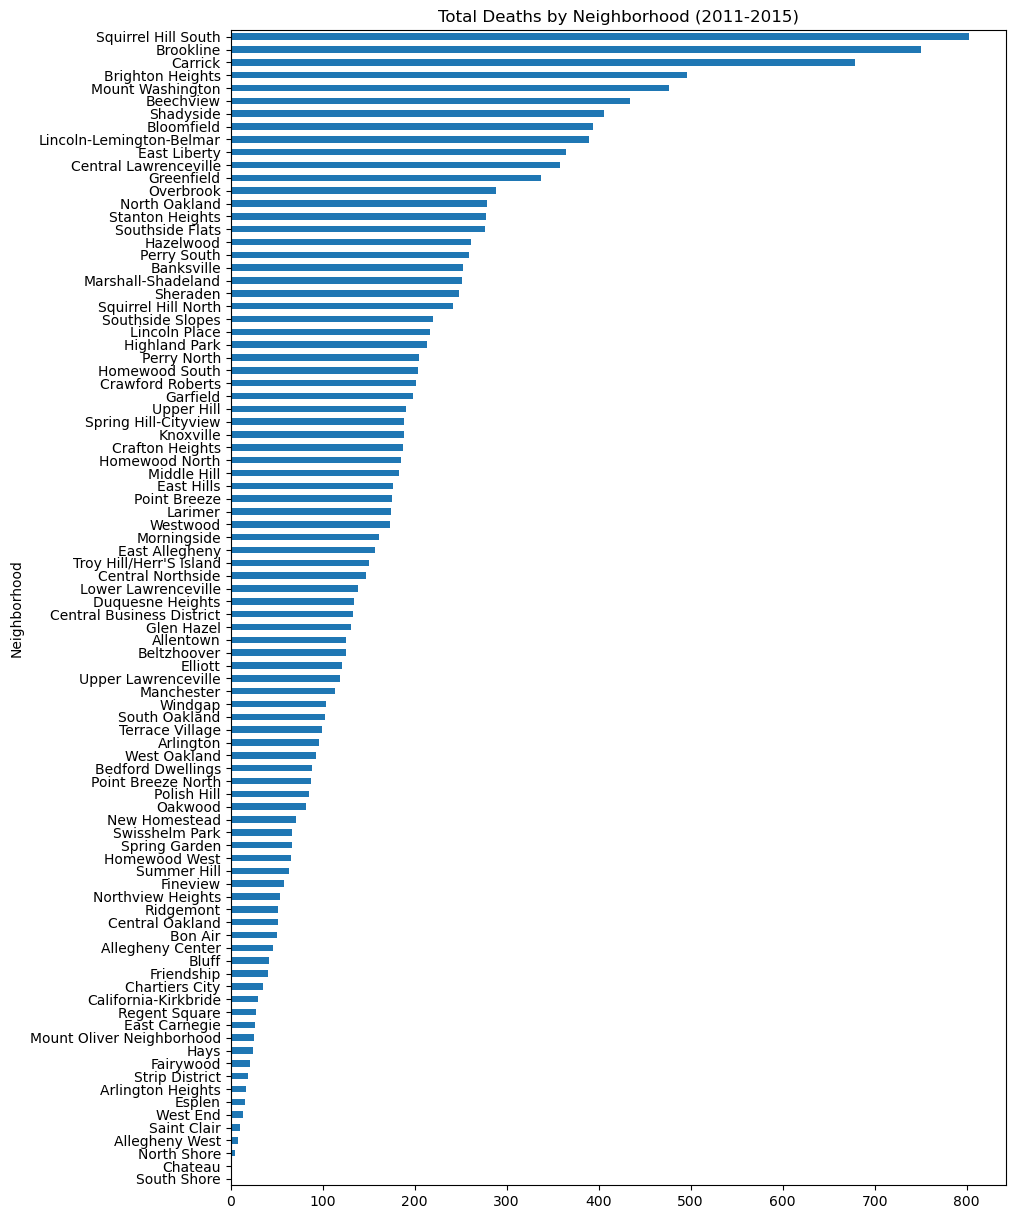

In [54]:
# Visualize the results in a bar graph
graph = data.plot.barh(x = "Neighborhood", y = "Total Deaths", title = "Total Deaths by Neighborhood (2011-2015)", figsize = (10, 15), legend = False)

In [55]:
# Make a new Series based on the order of the sorted data for Total Deaths
# Make a copy to avoid changing the reference later on
death_scores = pd.Series(data.copy().index + 1, index = data["Neighborhood"].copy())
print("Ordering by Total Deaths")

for key, value in death_scores.items():
    if value > 10:
        continue
    print(f"{value}: {key}")
print("...")
print(f"{death_scores.iloc[-1]}: {death_scores.index[-1]}")
# The order is the same as the reverse order of the bar graph above

Ordering by Total Deaths
1: South Shore
2: Chateau
3: North Shore
4: Allegheny West
5: Saint Clair
6: West End
7: Esplen
8: Arlington Heights
9: Strip District
10: Fairywood
...
90: Squirrel Hill South


---

### Median Age at Death

With total deaths score found, we can now go to the median age at death score. As said previously, *South Shore* and *Chateau* will be the top 2 as they had the lowest amount of total deaths anyways. For the rest, however, the median age at death is also important and might change up the submetric values.

Because the DataFrame already has the top 2 for median age at death already in the correct ordering, we can slice the DataFrame and only sort the remaining rows by the median age at death, this time in descending order because a higher median age at death is considered better as that means more life can be lived.

In [56]:
# Slice the list then sort that portion, skipping the first 2 rows
data[2:] = data[2:].sort_values("Total Median Age at Death", ascending = False)

# Print out the new first 10 rows
data.head(10)

,Neighborhood,Total Deaths,Total Median Age at Death
0,South Shore,0.0,0.0
1,Chateau,2.0,NaN
2,Squirrel Hill South,802.0,85.9
3,North Oakland,279.0,85.6
4,Banksville,253.0,85.5
5,Point Breeze,175.0,85.1
6,Squirrel Hill North,242.0,85.0
7,Central Oakland,52.0,84.0
8,New Homestead,71.0,83.4
9,Swisshelm Park,67.0,83.1


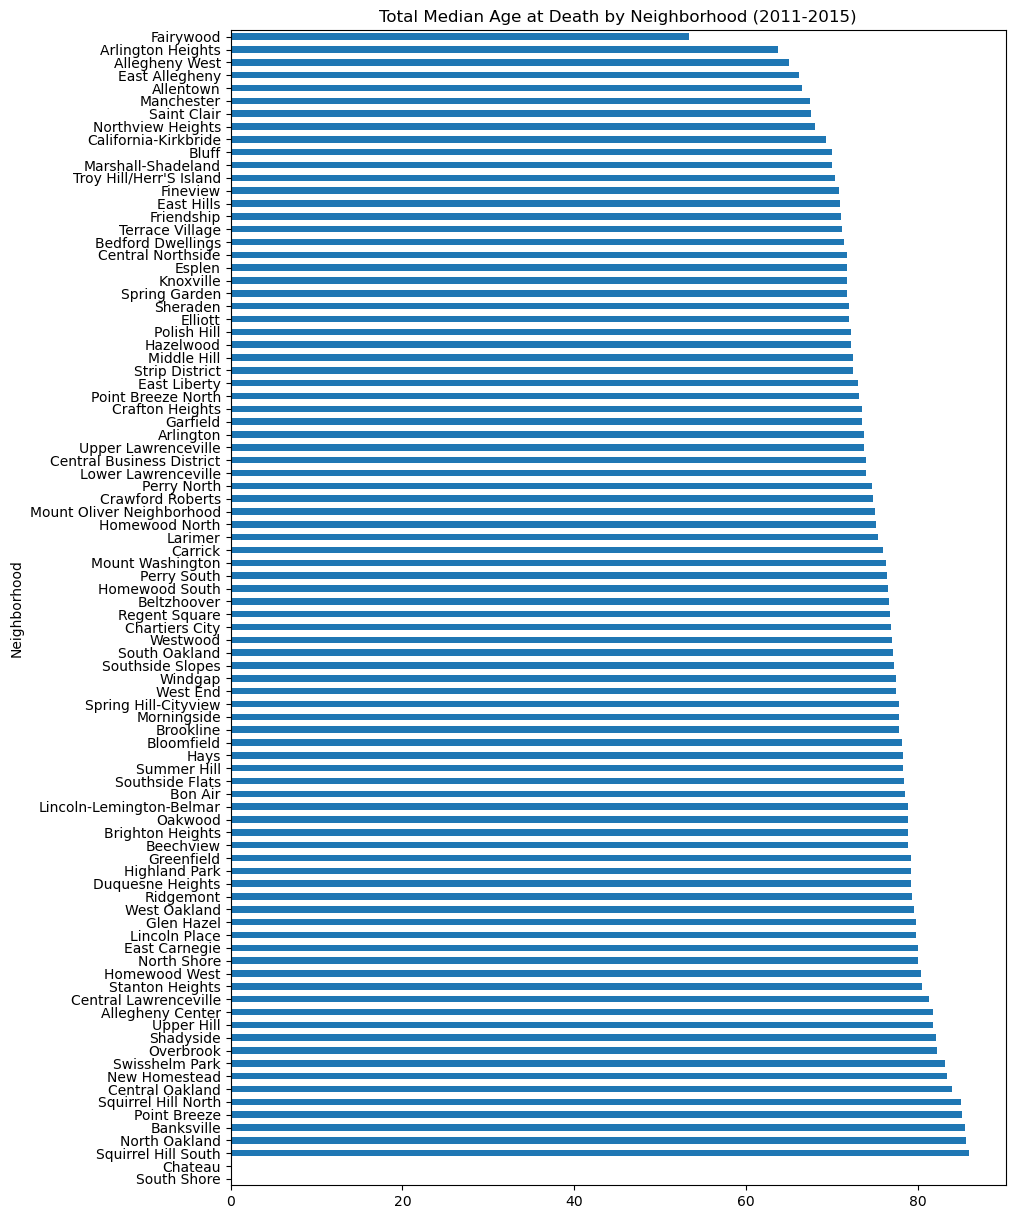

In [57]:
# Visualize the results in a bar graph
graph = data.plot.barh(x = "Neighborhood", y = "Total Median Age at Death", title = "Total Median Age at Death by Neighborhood (2011-2015)", figsize = (10, 15), legend = False)

In [58]:
# Make a new Series based on the order of the sorted data for Total Median Age at Death
# Again, use copy() to avoid changing the reference (though not as necessary here as before)
median_scores = pd.Series(data.copy().index + 1, index = data["Neighborhood"].copy())
print("Ordering by Total Median Age at Death")
for key, value in median_scores.items():
    if value > 10:
        continue
    print(f"{value}: {key}")
print("...")
print(f"{median_scores.iloc[-1]}: {median_scores.index[-1]}")
# The order is the same as the reverse order of the bar graph above

Ordering by Total Median Age at Death
1: South Shore
2: Chateau
3: Squirrel Hill South
4: North Oakland
5: Banksville
6: Point Breeze
7: Squirrel Hill North
8: Central Oakland
9: New Homestead
10: Swisshelm Park
...
90: Fairywood


---

### Submetric

Now that both scores are found, we can combine them to find the final submetric. To reiterate, the scores from the data will be summed and then there will be a final order. This final order will then be used as the submetric for this dataset.

In [59]:
# Make a new Series that holds the submetric score for each neighborhood by adding together the scores of each individual data point
submetric = death_scores + median_scores
submetric = submetric.sort_values()

# Update the submetric to use the new order. This accesses every value and sets it to be its (sorted) position using 1-indexing
submetric[:] = range(1, len(submetric) + 1)

# No need to display the results here as there is a graph for that
# # Display the results
# print("Submetric scores for each neighborhood")
# for key, value in submetric.items():
#     print(f"{key}: {value}")

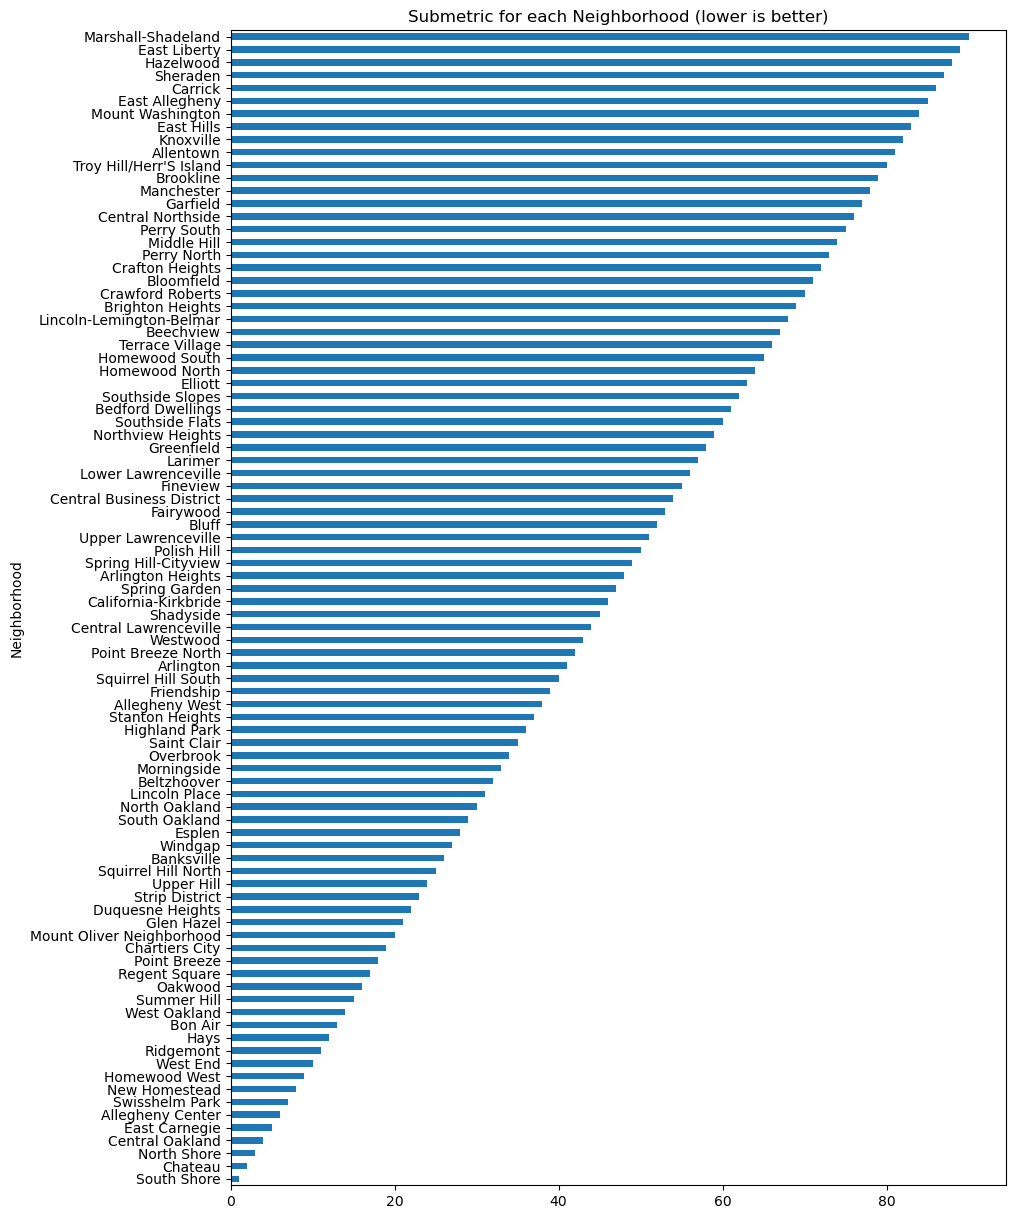

In [60]:
graph = submetric.plot.barh(title = "Submetric for each Neighborhood (lower is better)", figsize = (10, 15))

---

### Conclusion

In conclusion, from this dataset, we determined that the submetric should be the ranking of the neighborhoods using the total deaths and median age at death as the data points. To get the submetric, the order of the neighborhoods in the sorted list of the sum of scores from the sorted data points was used (which sounds really complicated, but hopefully is explained well previously). This way of getting the submetric doesn't take into account any of the values of the data points themsevles, only their relative ordering between all the neighborhoods. To correct the missing or inacccurate median at age of death data, the total deaths was used to give the position. This resulted in both *South Shore* and *Chateau* to be placed into first and second of that data point's ranking. This was seen as a fair compromise for their low total deaths, which was then seen as more important (so as to not punish these neighborhoods, which is explained prior). From this, it makes sense that the top 2 are *South Shore* and *Chateau* using this submetric. Next, in 3rd place was *North Shore*, which came in 3rd for total deaths, only having 5, and coming in 18th place for median age at death with 80yrs old. While *Squirrel Hill South* came in 3rd place for the median age at death, it came in last place for number of deaths, having about 800 deaths looking at the bar graph. The interpretation of this data likely means that many older people are dying in *Squirrel Hill South*, maybe due to having a larger number of older people to explain this. Of course, this analysis of the dataset doesn't include the population demographics, which could be seen as the next logical step to understanding this data better. But, for the purposes of the submetric, we conclude that *South Shore* is the best neighborhood according to this submetric, which takes into account the total deaths and median age at death for each neighborhood.

### Bonus

Visualizations and summary statistics to better understand the data for the entirety of Pittsburgh (obviously has nothing to do with ranking the neighborhoods):

,Total Deaths,Total Median Age at Death
count,90.000000,89.000000
mean,171.211111,74.848315
std,158.504988,9.736227
min,0.000000,0.000000
25%,55.000000,72.000000
50%,133.500000,76.500000
75%,219.250000,79.200000
max,802.000000,85.900000


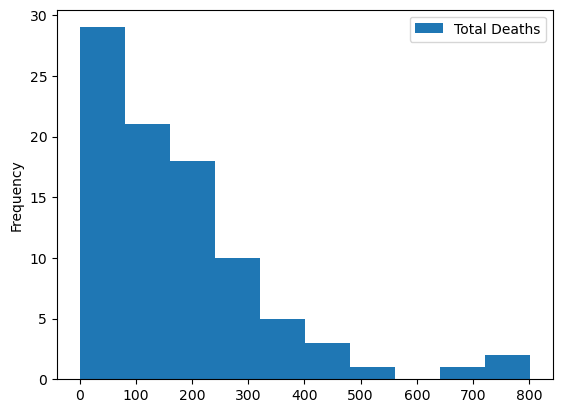

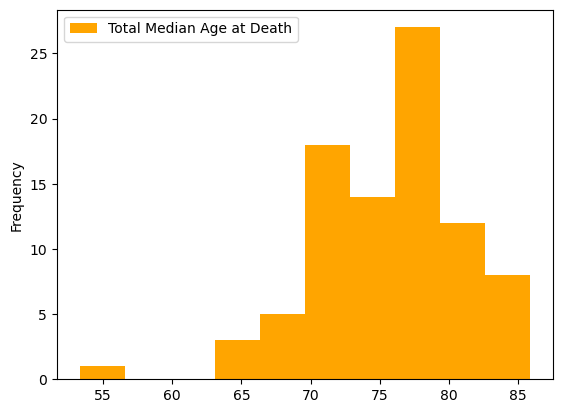

In [62]:
graph = data.plot.hist(x = "Neighborhood", y = "Total Deaths")
graph = data[2:].plot.hist(x = "Neighborhood", y = "Total Median Age at Death", color = "orange")
data.describe()

The first histogram shows the frequency of total deaths within a range. Clearly, the data is right-skewed with a median of 133.5 deaths and a mean of about 171.211111 deaths.

The second histogram shows the frequency of median age at death within a range. The data is slightly left-skewed with a median of 76.5yrs and a mean of about 74.848315yrs.

In [61]:
# Export a csv file of the results of the submetric for use in the final notebook
sub_df = submetric.reset_index()
sub_df.columns = ["Neighborhood", "Submetric Score"]
sub_df.set_index("Neighborhood").to_csv("median_age_at_death_submetric.csv")

# mjs556 Traffic Data Analysis

### Intro

This dataset tracks traffic data throughout the various neighborhoods.  I chose to focus on the average_daily_car_traffic column as I felt it was the best overall metric for how busy an area would be, and how annoying it would be to drive in, so a lower average_daily_car_traffic would mean a better driving experience and a better neighborhood.  This dataset is formatted so that each row  is an individual tracker, and there are multiple trackers per neighborhood.

I include the read_csv function for both the original name of the file from wrpdc and the file that I renamed, so that this code will run with the other git files, or on its own with the csv from wrpdc.

In [63]:
import pandas as pd

#Original Name
df = pd.read_csv("6dfd4f8f-cbf5-4917-a5eb-fd07f4403167.csv")

#Renamed File
#df = pd.read_csv("PittsburghTrafficData.csv")

print(len(df))
df.head()

420


,_id,id,device_id,record_oid,count_start_date,count_end_date,average_daily_car_traffic,average_daily_bike_traffic,counter_number,counter_type,...,longitude,latitude,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone
0,1,1011743669,85,1.445865e+09,2019-04-18,2019-04-26,4949.0,NaN,6,StatTrak,...,-79.967772,40.455733,Polish Hill,7.0,6.0,42003060500,6.0,6.0,2.0,2-6
1,2,1026101993,140,1.121444e+09,2019-01-24,NaN,NaN,NaN,NaN,Intersection Study,...,-79.952249,40.466157,Central Lawrenceville,7.0,9.0,42003090200,2.0,9.0,2.0,3-6
2,3,1032382575,11,1.539893e+09,2018-08-28,2018-09-04,NaN,NaN,NaN,NaN,...,-80.076469,40.460717,Windgap,2.0,28.0,42003563000,5.0,28.0,6.0,1-16
3,4,103627606,9,7.341951e+08,2018-07-17,2018-08-01,2741.0,NaN,NaN,StatTrak,...,-79.914335,40.437379,Squirrel Hill South,5.0,14.0,42003140800,3.0,14.0,4.0,2-18
4,5,1039546167,144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-80.019211,40.490794,Perry North,1.0,26.0,42003260200,1.0,26.0,1.0,1-15


### Data Setup

The first step after importing are data is cleaning and reorganizing it.  We need make sure that we only include trackers that have data for avg daily car traffic, and as it turns out, around 100 trackers across 10 neighborhood's are missing that data, so we need to drop them.

In [64]:
print("Missing neighborhoods: ",len(df["neighborhood"].unique()) - len(df.dropna(subset=["average_daily_car_traffic"])["neighborhood"].unique()))
print("Missing trackers:",len(df) - len(df.dropna(subset=["average_daily_car_traffic"])))

Missing neighborhoods:  10
Missing trackers: 134


In [65]:
df = df.dropna(subset=["average_daily_car_traffic"])

Next, we need to set up the data for graphing.  Since there are multiple trackers per neighborhood, just plotting the data as is will only compare traffic data across the individual trackers.  We need to group by neighborhoods, and then take the mean of the daily traffic so we can compare the avg daily traffic across all the trackers for each neighborhood.

In [66]:
grouped_df = df.groupby(by="neighborhood")
grouped_df.head()

,_id,id,device_id,record_oid,count_start_date,count_end_date,average_daily_car_traffic,average_daily_bike_traffic,counter_number,counter_type,...,longitude,latitude,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone
0,1,1011743669,85,1.445865e+09,2019-04-18,2019-04-26,4949.0,NaN,6,StatTrak,...,-79.967772,40.455733,Polish Hill,7.0,6.0,42003060500,6.0,6.0,2.0,2-6
3,4,103627606,9,7.341951e+08,2018-07-17,2018-08-01,2741.0,NaN,NaN,StatTrak,...,-79.914335,40.437379,Squirrel Hill South,5.0,14.0,42003140800,3.0,14.0,4.0,2-18
5,6,1041392556,76,5.713472e+08,2019-03-22,2019-03-29,1046.0,NaN,2,StatTrak,...,-80.014234,40.458106,Central Northside,6.0,25.0,42003250300,1.0,25.0,1.0,1-21
7,8,1053645660,87,8.042089e+08,2019-04-18,2019-04-26,3015.0,NaN,4,StatTrak,...,-79.964592,40.457119,Polish Hill,7.0,6.0,42003060500,6.0,6.0,2.0,2-6
10,11,1102260248,8,1.088318e+09,2018-07-16,2018-08-01,5592.0,NaN,NaN,StatTrak,...,-79.911925,40.435620,Squirrel Hill South,5.0,14.0,42003140800,3.0,14.0,4.0,2-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382,1226,504395374,401,1.119323e+09,2021-05-11,2021-05-19,2523.0,NaN,6,StatTrak,...,-79.991510,40.462082,Spring Hill-City View,1.0,24.0,42003262000,1.0,24.0,1.0,1-24
389,1321,434083600,408,1.452803e+09,2021-06-03,2021-06-11,2465.0,NaN,6,StatTrak,...,-79.869628,40.454185,East Hills,9.0,13.0,42003130600,2.0,13.0,5.0,3-19
393,1325,284761113,412,1.486634e+09,2021-06-03,2021-06-11,2585.0,NaN,2,StatTrak,...,-79.965519,40.440818,West Oakland,6.0,4.0,42003040200,3.0,4.0,4.0,2-10
402,1361,5216219,421,1.382452e+09,2021-06-29,2021-07-07,5605.0,NaN,7,StatTrak,...,-79.926715,40.425958,Greenfield,5.0,15.0,42003151700,3.0,15.0,4.0,2-15


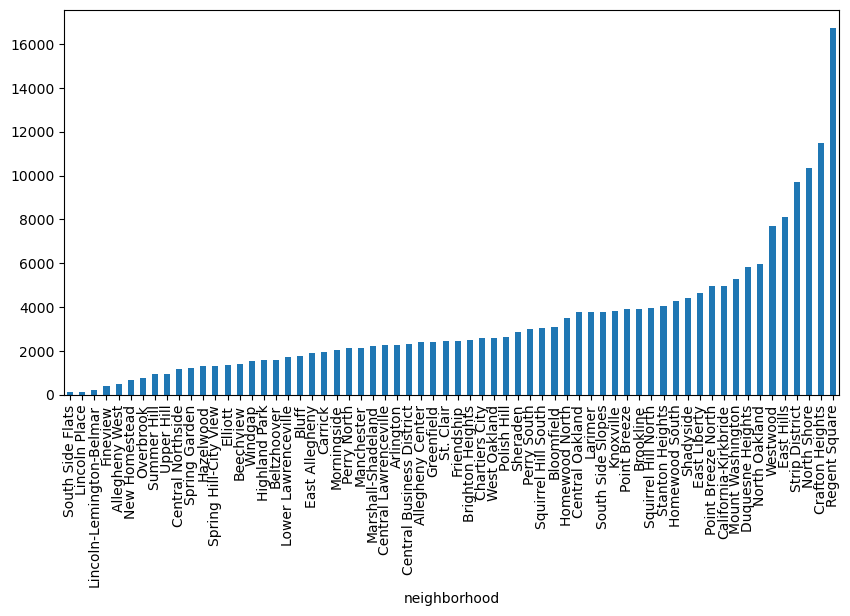

In [67]:
import matplotlib.pyplot as plt

grouped_df['average_daily_car_traffic'].mean().sort_values(ascending=True).plot(kind='bar', figsize=(10,5))
plt.show()

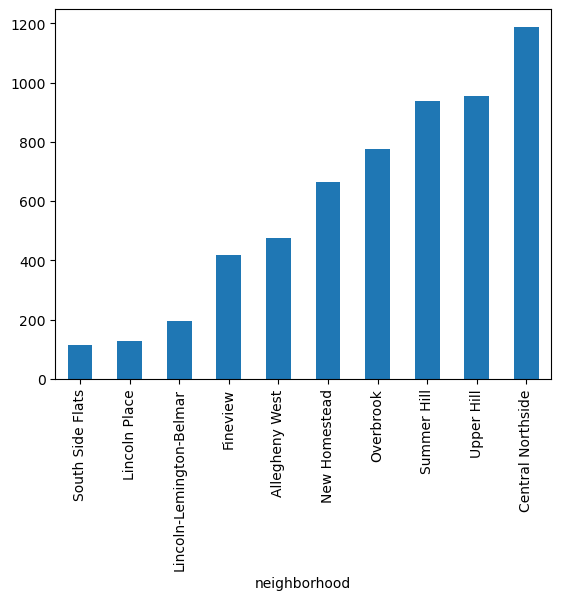

In [68]:
import matplotlib.pyplot as plt

grouped_df['average_daily_car_traffic'].mean().sort_values(ascending=True).head(10).plot(kind='bar')
plt.show()

In [69]:
final_df = grouped_df['average_daily_car_traffic'].mean().sort_values(ascending=True)
final_df.head()

neighborhood
South Side Flats            115.0
Lincoln Place               126.0
Lincoln-Lemington-Belmar    195.0
Fineview                    419.0
Allegheny West              477.0
Name: average_daily_car_traffic, dtype: float64

### Results

We can see that according to the traffic data, South Side Flats is the best neighborhood, because its low traffic makes it very easy and calm to drive around in.  Finally, we export the data for later use.


In [70]:
final_df.to_csv('traffic_final_data.csv')

### Limitations
The biggest limitation for this dataset is the spread of datapoints.  Out of the 90 neighborhoods in Pittsburgh, this dataset only has information on 64 of them, so it isn't a complete representation of the city, and this will cause problems in integrating this dataset with the other two, but that will be talked about more in the final notebook.

# str116 Crime Data Analysis

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

crime = 'bd41992a-987a-4cca-8798-fbe1cd946b07.csv'
pd.read_csv(crime, low_memory = False)

,_id,Report_Number,ReportedDate,ReportedTime,Hour,DayofWeek,ReportedMonth,NIBRS_Coded_Offense,NIBRS_Offense_Code,NIBRS_Offense_Category,NIBRS_Offense_Type,NIBRS_Crime_Against,NIBRS_Offense_Grouping,Violation,XCOORD,YCOORD,Zone,Tract,Neighborhood,Block_Address
0,1,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,13A AGGRAVATED ASSAULT,13A,Assault Offenses,Aggravated Assault,Person,A,18 2718 A1 Strangulation Basic - Applying,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
1,2,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,13C INTIMIDATION,13C,Assault Offenses,Intimidation,Person,A,18 2706 A1 Terroristic Threats-General,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
2,3,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,90Z ALL OTHER OFFENSES,90Z,All other Offenses,All other Offenses,Group B,B,75 3733 A Fleeing or Attempting To Elude Polic...,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
3,4,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,23H ALL OTHER LARCENY,23H,Larceny/Theft Offenses,All Other Larceny,Property,A,18 3921 A Theft by Unlawful Taking-Movable – L...,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
4,5,PGHP24000017,2024-01-01,00:21,0,Monday,Jan,9999 Vehicle Offense (Not NIBRS Reportable),999,Not NIBRS Reportable,Not NIBRS Reportable,Group B,B,LO 6 101 Discharge of Firearms Prohibited,-80.0243,40.4582,Zone 1,2107,Manchester,"1200 Block of COLUMBUS AVE Pittsburgh, PA"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76172,76173,PGHP25134833,2025-09-01,20:52,20,Monday,Sep,13B SIMPLE ASSAULT,13B,Assault Offenses,Simple Assault,Person,A,18 2701 A1 Simple Assault-General,-79.9652,40.4491,Zone 2,NaN,NaN,"500 BLOCK OF HERRON AVE PITTSBURGH, PA"
76173,76174,PGHP25134833,2025-09-01,20:52,20,Monday,Sep,90Z ALL OTHER OFFENSES,90Z,All other Offenses,All other Offenses,Group B,B,18 907 A Possess Instruments of Crime with Intent,-79.9652,40.4491,Zone 2,NaN,NaN,"500 BLOCK OF HERRON AVE PITTSBURGH, PA"
76174,76175,PGHP25134833,2025-09-01,20:52,20,Monday,Sep,13C INTIMIDATION,13C,Assault Offenses,Intimidation,Person,A,18 2706 A1 Terroristic Threats-General,-79.9652,40.4491,Zone 2,NaN,NaN,"500 BLOCK OF HERRON AVE PITTSBURGH, PA"
76175,76176,PGHP25134833,2025-09-01,20:52,20,Monday,Sep,520 WEAPON LAW VIOLATIONS,520,Weapon Law Violations,Weapon Law Violations,Society,A,"18 6105 A1 Persons Not to Possess, Use, Manufa...",-79.9652,40.4491,Zone 2,NaN,NaN,"500 BLOCK OF HERRON AVE PITTSBURGH, PA"


### What can we understand from this?

On the surface, this CSV file is titled in a way that makes the data seem like it's contained in only the most recent month. However, upon inspection, the data actually measures the total crime in 2025, leading up to the last full month. In order to extract relevant information from this, we must consider what data brings us to a metric that could be deemed worthy of a 'best neighborhood'. To be clear, we need a way to group crime quantities on a per-neighborhood basis, whilst also having a unique way to identify them. The most relevant columns for this, after converting the CSV into a DataFrame, are '_id' and 'Neighborhood.' This is because '_id' acts as an incidence number from the first crime of 2025 all the way up to the latest crime reported. To accurately utilize this column, the 'Neighborhood' column keeps track of every crime committed within a specific neighborhood. By grouping all like neighborhoods, the unique id number can be summed to determine the total number of crimes committed/reported within a certain neighborhood. 

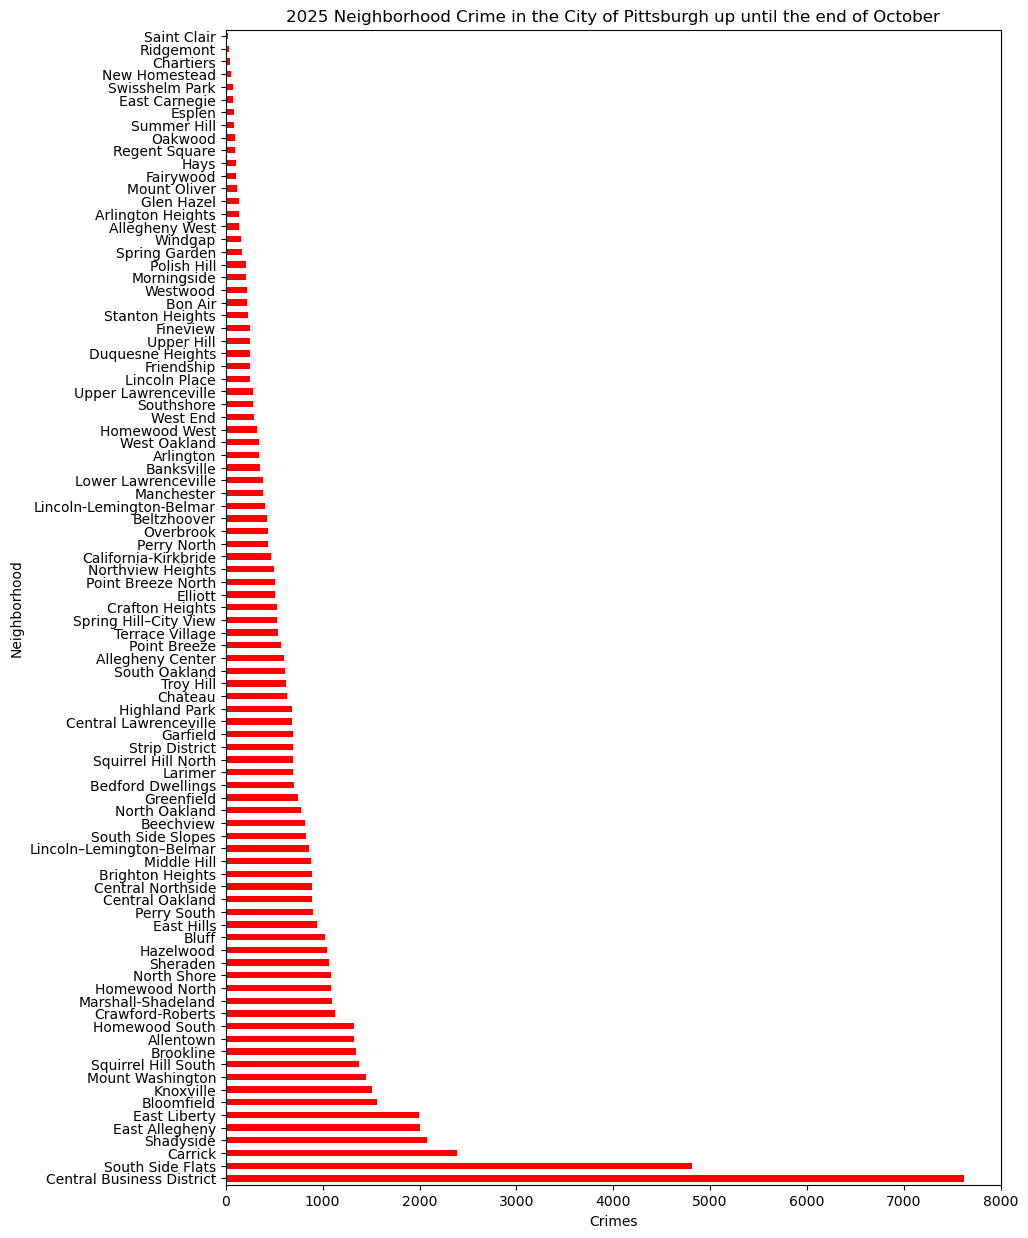

In [84]:
neighborhood_crime = ['_id','Neighborhood']
df = pd.read_csv(crime, usecols = neighborhood_crime)
quant = df['Neighborhood'].value_counts()
quant.plot.barh(figsize = (10,15), color = 'red')
plt.title("2025 Neighborhood Crime in the City of Pittsburgh up until the end of October")
plt.xlabel("Crimes")
plt.show()
last_20 = quant.iloc[-20:]

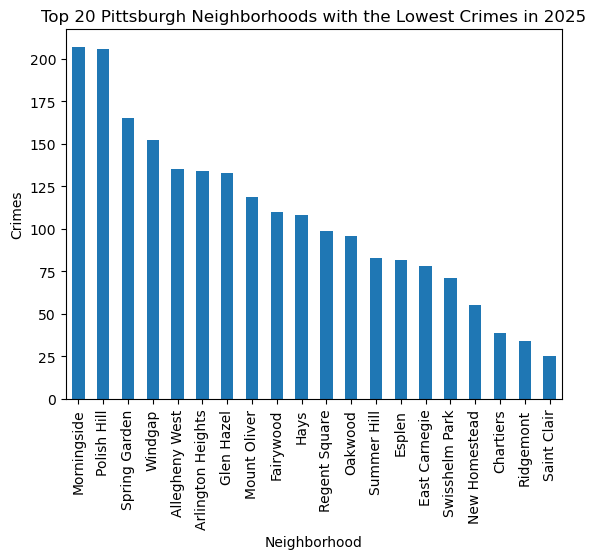

In [85]:
lowest_crime = last_20.plot.bar()
plt.xlabel("Neighborhood")
plt.ylabel("Crimes")
plt.title("Top 20 Pittsburgh Neighborhoods with the Lowest Crimes in 2025")
plt.show()

### What did we find?

After extracting the data from the monthly crime value, I sorted by neighborhoods that were grouped significantly by each unique id number, which was capable of gauging the quantity of crimes committed in 2025 per neighborhood. I then took this data and formulated it into a bar chart of only the neighborhoods with the lowest amount of crimes. I was then able to conclude that Saint Clair could be considered the safest neighborhood by this yearly crime metric in the city of Pittsburgh. This can be better conveyed by assigning a submetric for each neighborhood based on how few crimes have been committed.

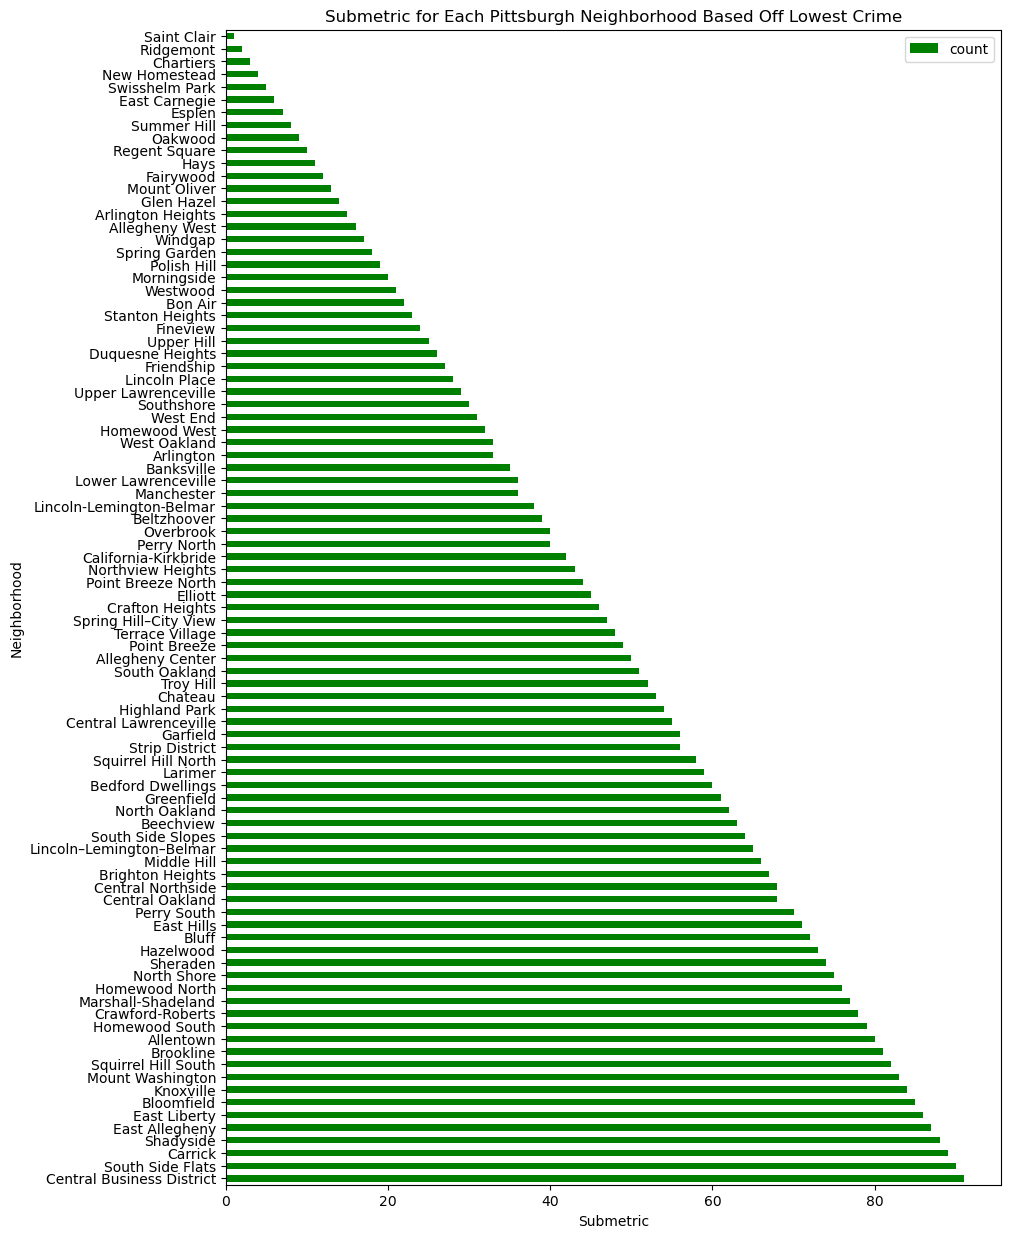

In [86]:
sorted_quant = quant.sort_values(ascending = False)
submetrics = sorted_quant.rank(method = 'min', ascending = True)
submetrics_df = pd.DataFrame(submetrics)
submetrics_plot = submetrics_df.plot.barh(figsize = (10,15), color = 'green', xlabel = "Submetric", ylabel = "Neighborhood")
plt.title("Submetric for Each Pittsburgh Neighborhood Based Off Lowest Crime")
plt.show()

As we can see, by sorting into a submetrics DataFrame, Saint Clair remains at the top for what we define as the 'safest neighborhood.' After which, the rest of the neighborhoods follow suit. By accumulating every neighborhood, and assigning each neighborhood a submetric similar to a 'rank', we may define each of the datasets into one overall average metric. By doing so, we can determine what the overall best neighborhood is. 

In [87]:
crc = submetrics_df.to_csv('unfinished_crime_submetric.csv', index = True)
crc = pd.read_csv('unfinished_crime_submetric.csv')
crc_df = (crc.rename(columns = {'count' : 'Submetric Score'}).sort_values(by = 'Submetric Score', ascending = True))
crc_df['Submetric Score'] = crc_df['Submetric Score'].round().astype(int)
crc_df.to_csv('crime_submetrics.csv', index = None)

### Conclusion

To conclude, based on the present data collected from this dataset, we may determine that Saint Clair may be considered to be the safest or 'best' neighborhood. This is due to a survey on total crime in the year 2025, leading up to September. The quantity of crimes remained fewer than in any other neighborhood and therefore made it plausible to assign a rank of 1.

### What are some limitations?

Some limitations of this study are the lack of consideration for types of neighborhoods where underreporting may be more common. Not every neighborhood has the same stance on reporting and might handle issues more in-house. There is also the idea that if some of these neighborhoods just have a lower population, then the number of crimes would just be smaller than in a bigger area of the city.

# Combined Final Data

In [88]:
import pandas as pd

traffic_path = 'traffic_final_data.csv'
traffic_data = pd.read_csv(traffic_path)
traffic_data["Rank"] = range(1, len(traffic_data["average_daily_car_traffic"])+1)
traffic_data = traffic_data.rename(columns={"neighborhood":"Neighborhood"})
traffic_data.head(10)

,Neighborhood,average_daily_car_traffic,Rank
0,South Side Flats,115.000000,1
1,Lincoln Place,126.000000,2
2,Lincoln-Lemington-Belmar,195.000000,3
3,Fineview,419.000000,4
4,Allegheny West,477.000000,5
5,New Homestead,666.000000,6
6,Overbrook,777.000000,7
7,Summer Hill,937.000000,8
8,Upper Hill,953.333333,9
9,Central Northside,1189.000000,10


---

In [89]:
death_data = pd.read_csv('median_age_at_death_submetric.csv')
death_data.head(10)

,Neighborhood,Submetric Score
0,South Shore,1
1,Chateau,2
2,North Shore,3
3,Central Oakland,4
4,East Carnegie,5
5,Allegheny Center,6
6,Swisshelm Park,7
7,New Homestead,8
8,Homewood West,9
9,West End,10


In [90]:
crime_data = pd.read_csv('crime_submetrics.csv')
crime_data.tail(10)


,Neighborhood,Submetric Score
81,Squirrel Hill South,82
82,Mount Washington,83
83,Knoxville,84
84,Bloomfield,85
85,East Liberty,86
86,East Allegheny,87
87,Shadyside,88
88,Carrick,89
89,South Side Flats,90
90,Central Business District,91


### Data cleaning

Before we can combine the datasets, we need to make sure the neighborhood names are consistent.  We can compare the neighborhood columns as sets to see where the differences are, and then clean the data based on what we found.

In [91]:
print(sorted(set(death_data["Neighborhood"]) - set(crime_data["Neighborhood"])))
print(sorted(set(crime_data["Neighborhood"]) - set(death_data["Neighborhood"])))

['Chartiers City', 'Crawford Roberts', 'Mount Oliver Neighborhood', 'South Shore', 'Southside Flats', 'Southside Slopes', 'Spring Hill-Cityview', "Troy Hill/Herr'S Island"]
['Chartiers', 'Crawford-Roberts', 'Lincoln–Lemington–Belmar', 'Mount Oliver', 'South Side Flats', 'South Side Slopes', 'Southshore', 'Spring Hill–City View', 'Troy Hill']


In [92]:
set(traffic_data["Neighborhood"]) - (set(death_data["Neighborhood"]) & set(crime_data["Neighborhood"]))
#St. Clair is Saint Clair in the others

{'Chartiers City',
 'South Side Flats',
 'South Side Slopes',
 'Spring Hill-City View',
 'St. Clair'}

In [93]:
def clean_names(df):
    df["Neighborhood"] = df["Neighborhood"].str.lower()
    df["Neighborhood"] = df["Neighborhood"].str.replace(" ", "")
    df["Neighborhood"] = df["Neighborhood"].str.replace("-", "")
    df["Neighborhood"] = df["Neighborhood"].str.replace("–", "")
    df["Neighborhood"] = df["Neighborhood"].str.replace("city", "")
    df["Neighborhood"] = df["Neighborhood"].str.replace("neighborhood", "")
    df["Neighborhood"] = df["Neighborhood"].str.replace("/herr'sisland", "")
    df["Neighborhood"] = df["Neighborhood"].str.replace("st.", "saint")


    return df

traffic_data = clean_names(traffic_data)
death_data = clean_names(death_data)
crime_data = clean_names(crime_data)


After the data preproccesing, we can see that the names are now consistent across the datasets.

In [94]:
print(sorted(set(death_data["Neighborhood"]) - set(crime_data["Neighborhood"])))
print(sorted(set(crime_data["Neighborhood"]) - set(death_data["Neighborhood"])))

[]
[]


In [95]:
set(traffic_data["Neighborhood"]) - (set(death_data["Neighborhood"]) & set(crime_data["Neighborhood"]))

set()

### Final Rankings

Each of the datasets is ranked based on its own metric, so we can combine the different metrics by adding up the neighborhoods positional rankings (1 meaning they did the best in that metric), and the lower the result the better.  However, traffic data only has 64 out of 90 neighborhoods, so in order to prevent bias towards neiborhoods not scored by traffic data, we set them to 32 (the median ranking of traffic data).

In [96]:
final_df = {}

#Add Traffic data
for index, row in traffic_data.iterrows():
    final_df[row["Neighborhood"]] = row['Rank']

#Add Crime data
for index, row in crime_data.iterrows():
    if row["Neighborhood"] not in final_df.keys():
        final_df[row["Neighborhood"]] = row['Submetric Score'] + 32   #If a neighborhood is not in traffic data, give it the median traffic ranking
    final_df[row["Neighborhood"]] += row['Submetric Score']

#Add Death data
for index, row in death_data.iterrows():
    if row["Neighborhood"] not in final_df.keys():
        final_df[row["Neighborhood"]] = row['Submetric Score']
    final_df[row["Neighborhood"]] += row['Submetric Score']


final_df = pd.Series(final_df)
final_df.sort_values().head()

newhomestead     18
summerhill       31
ridgemont        47
swisshelmpark    49
eastcarnegie     49
dtype: int64

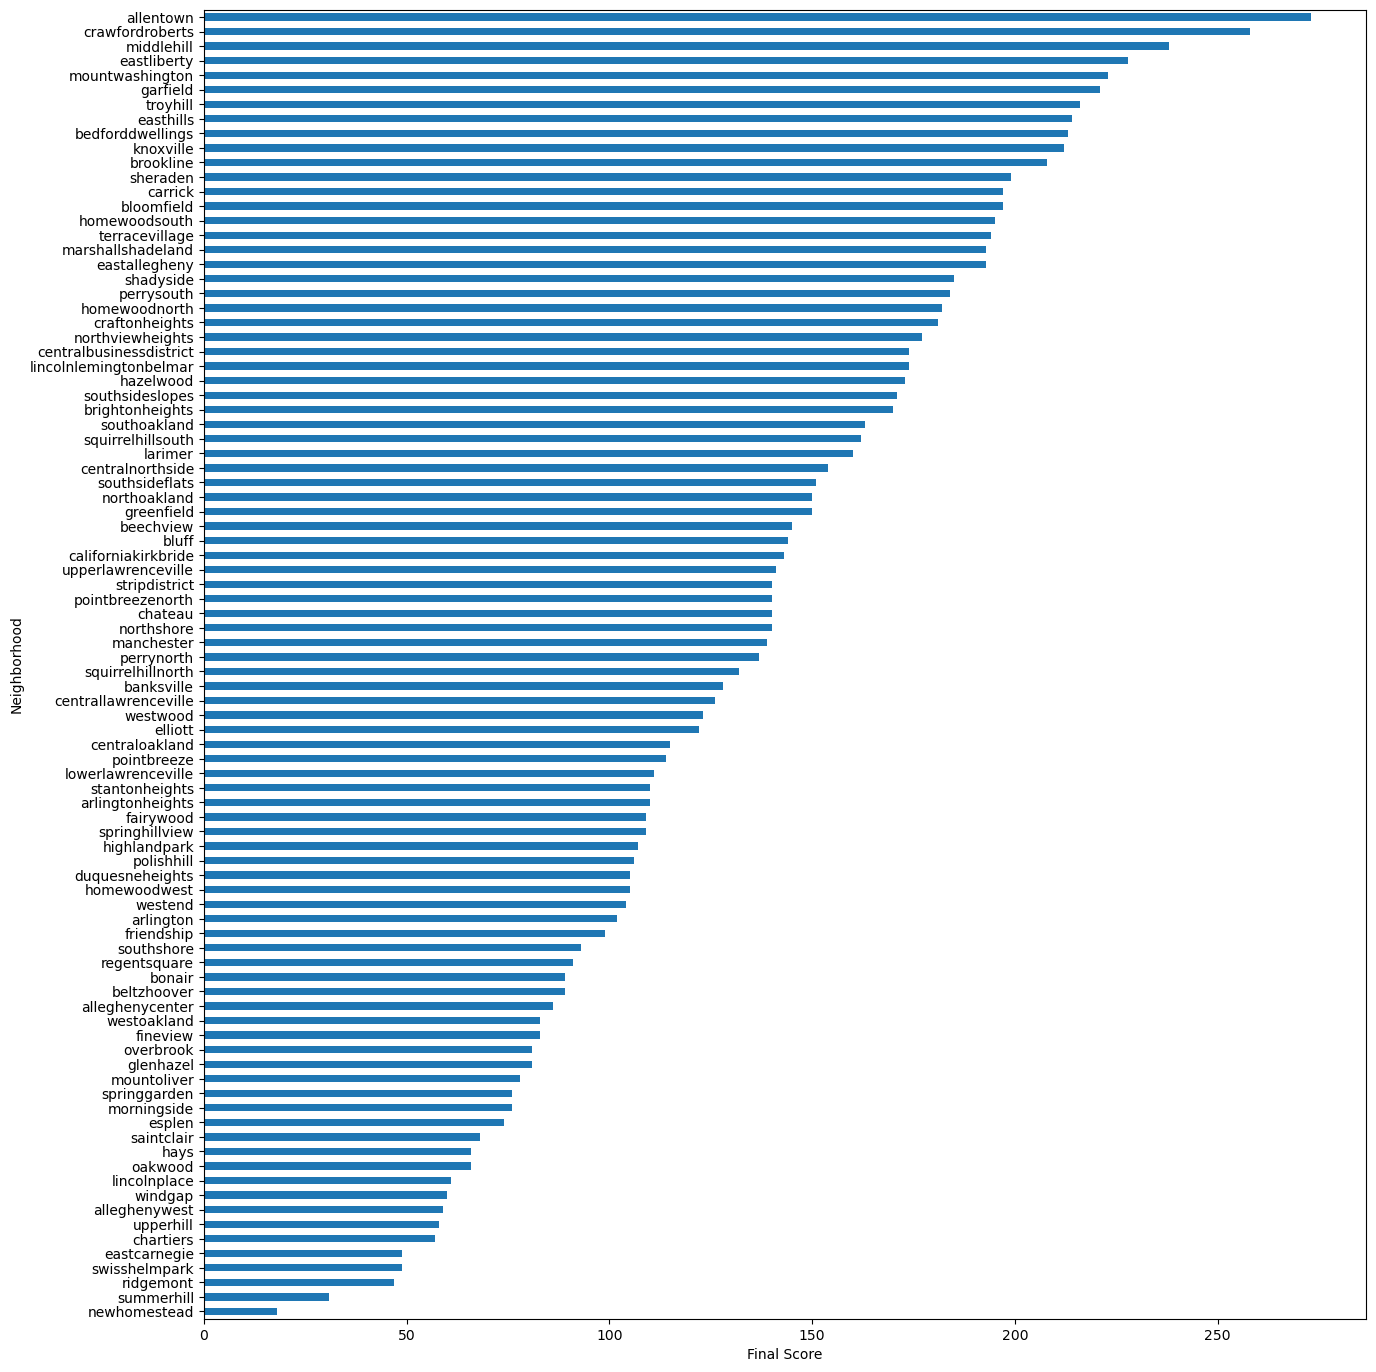

In [97]:
import matplotlib.pyplot as plt

final_df.sort_values(ascending=True).plot(kind='barh', figsize= (15, 17))
plt.xlabel("Final Score")
plt.ylabel("Neighborhood")
plt.show()

# Final Conclusion

Looking at the final rankings, we each found different conclusions within our submetrics that had our own 'best' neighborhood. Median age at death concluded South Shore by default, traffic data concluded South Side Flats, and criminal data concluded St. Clair. Despite this, a neighborhood that did not necessarily rank at the very top managed to come out on top. New Homestead, represents a well-rounded neighborhood, finishing comfortably within the top 10, and managed to receive the best, or lowest, submetric score. That New Homestead is the best neighborhood according to our metrics. This conclusion aims to balance some of what we believe to be the most valued traits when traditionally considering a neighborhood; in doing so, it managed to sacrifice high individual traits for overall good traits.  

Matt: I kind of have to say that Central Oakland is my favorite neighborhood, because I'm not from around here and I haven't really explored the other neighborhoods yet.  That being said, I still do like Oakland, and it would probably be at least in my top five even if I did know other neighborhoods.  I've never heard of New Homestead before this project, so I was surprised to see it take first place, but looking back at all of our metrics, it was consistently highly ranked, so it does make sense.

Manav: I personally prefer Oakland, particularly Central Oakland, as I have had the most good experiences in this neighborhood. The "best" neighborhood of New Homestead really came out of nowhere for me, as I wasn't considering the other submetrics and only had experience with my top 5 in my submetric of median age at death. Looking at the final data, it is good to see that Central Oakland is within the top 50%.

Steven: Despite the conclusions for my own dataset that Sin Clair would be considered the "best", if I had to select a neighborhood, I would choose Central Oakland. I can admit this decision comes from a shallow view of the city of Pittsburgh, as I haven't ventured elsewhere; however, that's the only neighborhood I can form a grounded opinion on. Through the dense population, walkable streets, and lively personalities, I couldn't imagine choosing anything else.